<a href="https://colab.research.google.com/github/LaisHellen/LaisHellen/blob/main/analise_dados_web_livros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UNIVERSIDADE FEDERAL DE SÃO CARLOS - UFSCar**

**Disciplina de Estudos Sociopolíticos dos Algorítmos e Inteligência Artificial**

TRABALHO FINAL

---

**Lais Hellen Santos**

# 1. Introdução

O presente trabalho tem como objetivo explorar e analisar a participação de autoras negras no Ranking geral de livros mais vendidos nos últimos 5 anos (2022-2018), organizado pela Publish News, um canal de principais fatos e opiniões relacionados ao mundo livreiro, no Brasil e no exterior[3].
Os livros mais vendidos são premiados com base na Lista de Mais Vendidos do PublishNews, de acordo com a posição final na listagem anual do ano anterior. Tal listagem contém os seguintes gêneros literários:

*   Ficção
*   Não Ficção
*   Auto Ajuda
*   Infantojuvenil
*   Negócios

Logo espera-se mostrar como é a cobertura das obras de autoras negras nesse ranking e fazer um paralelo com o tema de vieses abordados durante a disciplina, assim como comparar se a amostra reflete a procura dos títulos declarados como mais vendidos no Brasil, através de um breve experimento no Gtrends.



**1.1 Conjunto(s) de Dados**

O ranking de livros publicados pela Publish News é uma amostra das vendas de livros no Brasil, que conta com o auxílio de algumas livrarias e lojas de varejos que conforme o site, mandam listas de até 20 livros mais vendidos em cada categoria determinada. Logo, as posições a partir do 15º lugar, apresentam uma maior margem de erro, que não é muito detalhada no site. Os organizadores também informam que livros em domínio público não são contabilizados.

Dessa forma, a pesquisa procura analisar os dados das listas gerais anuais criadas entre os anos de 2018 e 2022, totalizando 100 obras literárias e seus respectivos autores (46 autorias distintas) e número de vendas, segundo informações fornecidas pelas seguintes livrarias:
*   A Página
*   Blooks
*   Cultura
*   Curitiba
*   Escariz
*   Leitura
*   Livraria Cameron
*   Livraria da Vila
*   Livraria LDM
*   Livraria Loyola
*   Livraria Santos
*   Livraria Vozes
*   Livruz
*   Loja Americanas
*   Magazine Luiza
*   Martins Fontes SP
*   Saraiva
*   Submarino
*   Travessa
*   Vitrola Livraria



---



# 2. Extração

**2.1 Extração dos Dados**

A coleta dos dados na página Publish News foi realizada através da técnica de mineração chamada Web Scrapping, com uso da linguagem de programação Python. Foi coletado listas separadas por ano. Da mesma forma que foi feita a lista de 2018 presente no código abaixo, foi feito as demais listas de 2019,2020, 2021 e 2022.

In [ ]:
import requests
r = requests.get('https://www.publishnews.com.br/ranking/anual/0/2018/0/0')
from bs4 import BeautifulSoup
soup = BeautifulSoup(r.text, 'html.parser')
results = soup.find_all('div', attrs={'class':'pn-ranking-livros-posicao clearfix'})
records = []
for result in results:
    posicao = result.find('div', attrs={'class':'pn-ranking-livros-posicao-numero'}).text # result not results
    nome = result.find('div', attrs={'class': 'pn-ranking-livro-nome'}).text
    autor = result.find('div', attrs={'class': 'pn-ranking-livro-autor'}).text
    editora = result.find('div', attrs={'class' : 'pn-ranking-livro-editora'}).text
    volume = result.find('div', attrs={'class':'pn-ranking-livros-posicao-volume'}).text

    records.append((posicao, nome, autor,editora, volume))

In [ ]:
print(records)

[('1', 'A sutil arte de ligar o foda-se', 'Mark Manson', 'Intrínseca', '439.251'), ('2', 'As aventuras na Netoland com Luccas Neto', 'Luccas Neto', 'Pixel', '377.036'), ('3', 'O milagre da manhã', 'Hal Elrod', 'BestSeller', '189.595'), ('4', 'Seja foda!', 'Caio Carneiro', 'Buzz', '165.595'), ('5', 'Combate espiritual', 'Padre Reginaldo Manzotti', 'Petra', '148.570'), ('6', 'Sapiens', 'Yuval Noah Harari', 'L&PM', '141.825'), ('7', 'O poder da ação', 'Paulo Vieira', 'Gente', '141.681'), ('8', 'O poder do hábito', 'Charles Duhigg', 'Objetiva', '125.664'), ('9', 'Felipe Neto - A vida por trás das câmeras', 'Felipe Neto', 'Pixel', '125.408'), ('10', 'O poder da autorresponsabilidade', 'Paulo Vieira', 'Gente', '119.337'), ('11', 'Textos cruéis demais para serem lidos rapidamente', 'Igor Pires da Silva / Gabriela Barreira', 'Globo Alt', '110.232'), ('12', 'Propósito', 'Sri Prem Baba', 'Sextante', '108.423'), ('13', 'Ainda sou eu', 'Jojo Moyes', 'Intrínseca', '105.968'), ('14', 'Me poupe!', 'N

In [ ]:
import pandas as pd
lista_2018 = pd.DataFrame(records, columns=['Posição', 'Nome', 'Autor', 'Editora', 'Volume'])
lista_2018

,Posição,Nome,Autor,Editora,Volume
0,1,A sutil arte de ligar o foda-se,Mark Manson,Intrínseca,439.251
1,2,As aventuras na Netoland com Luccas Neto,Luccas Neto,Pixel,377.036
2,3,O milagre da manhã,Hal Elrod,BestSeller,189.595
3,4,Seja foda!,Caio Carneiro,Buzz,165.595
4,5,Combate espiritual,Padre Reginaldo Manzotti,Petra,148.570
5,6,Sapiens,Yuval Noah Harari,L&PM,141.825
6,7,O poder da ação,Paulo Vieira,Gente,141.681
7,8,O poder do hábito,Charles Duhigg,Objetiva,125.664
8,9,Felipe Neto - A vida por trás das câmeras,Felipe Neto,Pixel,125.408
9,10,O poder da autorresponsabilidade,Paulo Vieira,Gente,119.337


In [ ]:
lista_2018.to_csv('lista_2018.csv')

In [ ]:
from google.colab import files
files.download('lista_2018.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**2.2 Dataframe único**

Após a extração das listas segmentadas por ano, foi feita a junção das mesmas via Google sheets e adicionada três colunas: Ano, Sexo e Etnia, para análise dos objetivos propostos.
A classificação do Sexo foi dado a partir da leitura dos nomes, e separados no que era tipicamente feminino e masculino. Já a classificação de Etnia foi dada através a avaliação manual de imagens das autorias presentes na internet.

Por questão de quantidade de dados e habilidades técnicas, não foi possível obter essas informações a partir de abordagens metodológicas mais reconhecidas. Mas é de minha ciência que é possivel essa validação com uso de algumas escalas de tons de pele e etnia, como a escala de Fitzpatrick[4], escala de etnia Lancer (LES) [1],ou modelo de aprendizagem de máquina, como estudo feito no Artigo "Toward to Reduction of Bias for Gender and Ethnicity"[2]

Para de normalização foi identificado e excluído um registro de 2018, com o título "O meu diário mágico", cuja autoria é uma instituição, a Ciranda Cultural, o que não faz sentido para a proposta do experimento e análise de dados. Além disso, a obra Textos cruéis demais para serem lidos rapidamente	foi escrito por Igor Pires da Silva e Gabriela Barreira, portanto, para contabilizar a presença feminina, a classificação do Sexo para esse registro foi dado como feminino.


In [ ]:
lista_livros = pd.read_csv('lista_livros.csv')
lista_livros

,Ano,Posição,Nome,Autoria,Editora,Volume,Etnia,Sexo
0,2018,1,A sutil arte de ligar o foda-se,Mark Manson,Intrínseca,439.251,Não Negra,Masculino
1,2018,2,As aventuras na Netoland com Luccas Neto,Luccas Neto,Pixel,377.036,Não Negra,Masculino
2,2018,3,O milagre da manhã,Hal Elrod,BestSeller,189.595,Não Negra,Masculino
3,2018,4,Seja foda!,Caio Carneiro,Buzz,165.595,Não Negra,Masculino
4,2018,5,Combate espiritual,Padre Reginaldo Manzotti,Petra,148.570,Não Negra,Masculino
...,...,...,...,...,...,...,...,...
94,2022,16,Especialista em pessoas,Tiago Brunet,Academia,41.070,Negra,Masculino
95,2022,17,Quem pensa enriquece: o legado,Napoleon Hill,Citadel,40.096,Não Negra,Masculino
96,2022,18,A garota do lago,Charlie Donlea,Faro Editorial,38.183,Não Negra,Masculino
97,2022,19,Todas as suas (im)perfeições,Colleen Hoover,Galera Record,37.963,Não Negra,Feminino




---



# 3. Tratamento dos Dados

**3. Análise Descritiva e Exploratória dos Dados**

A lista não possui nenhuma linha ausente e num dados vazio

In [ ]:
lista_livros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      99 non-null     int64  
 1   Posição  99 non-null     int64  
 2   Nome     99 non-null     object 
 3   Autoria  99 non-null     object 
 4   Editora  99 non-null     object 
 5   Volume   99 non-null     float64
 6   Etnia    99 non-null     object 
 7   Sexo     99 non-null     object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.3+ KB


A listagem dos últimos 5 anos, ordenada pelo número de vendas, revela Mark Manson como autor mais vendido no Brasil, em dois anos consecutivos, 2018 e 2019, com um total de 825.806 vendas para o mesmo título, A sutil Arte de ligar o fod*-se.
Fica notável que em ordem de quantidade vendida, as 5 primeiras posições é marjoritariamente Masculina e Branca.



In [ ]:
lista_livros.sort_values(by =['Volume'],ascending=[False])

,Ano,Posição,Nome,Autoria,Editora,Volume,Etnia,Sexo
0,2018,1,A sutil arte de ligar o foda-se,Mark Manson,Intrínseca,439.251,Não Negra,Masculino
19,2019,1,A sutil arte de ligar o foda-se,Mark Manson,Intrínseca,386.555,Não Negra,Masculino
1,2018,2,As aventuras na Netoland com Luccas Neto,Luccas Neto,Pixel,377.036,Não Negra,Masculino
20,2019,2,O milagre da manhã,Hal Elrod,BestSeller,257.451,Não Negra,Masculino
21,2019,3,Seja foda!,Caio Carneiro,Buzz,192.172,Não Negra,Masculino
...,...,...,...,...,...,...,...,...
55,2020,17,Escravidão -Vol 1,Laurentino Gomes,Globo Livros,37.780,Não Negra,Masculino
98,2022,20,"Vermelho, branco e sangue azul",Casey McQuiston,Seguinte,37.052,Não Negra,Feminino
56,2020,18,A revolução dos bichos,George Orwell,Companhia das Letras,33.807,Não Negra,Masculino
57,2020,19,21 lições para o século 21,Yuval Noah Harari,Companhia das Letras,32.166,Não Negra,Masculino


Ao todo se conta com 46 autorias que possuem no mínimo 1 livro no Ranking em algum ano entre o período de dados analisado

In [ ]:
lista_livros['Autoria'].nunique()

46

Na lista de maiores vendas por autoria, independentemente do título, homens lideram o Raking enquanto a primeira mulher aparece na 12ª posição (Colleen Hoover) e a primeira mulher negra (Gabriela Barreira) fica na 20ª posição da lista geral de mais vendidos ao longo do período analisado.

In [ ]:
vendas_autoria = lista_livros.groupby(by=['Autoria'])['Volume'].sum()
volume_autoria= pd.DataFrame(vendas_autoria)
#volumes_autores = sorted(vendas_autoria, key = Volume.get_valor)
#volumes_autores
volume_autoria.sort_values(by=['Volume'],ascending=[False])

,Volume
Autoria,
Mark Manson,1047.804
Paulo Vieira,717.961
Luccas Neto,572.830
Hal Elrod,548.929
Napoleon Hill,480.809
Caio Carneiro,404.557
Thiago Nigro,334.707
Padre Reginaldo Manzotti,326.649
T. Harv Eker,324.681


Ao agrupar a quantidade de vendas por gênero, vemos que disparadamente a quantidade de obras de autores vendidos é quase 4 vezes mais do que a quantidade de orbas vendidas de autoras entre 2018 e 2022

In [ ]:
vendas_por_sexo = lista_livros.groupby(by=['Sexo'])['Volume'].sum()
vendas_por_sexo

Sexo
Feminino     1902.679
Masculino    6891.256
Name: Volume, dtype: float64

Aqui é possivel verificar com mais detalhes a listagem dos mulheres presentes no Ranking

In [ ]:
#Selecionando dados de Mulheres
mulheres = lista_livros['Sexo'] == 'Feminino'
lista_mulheres = lista_livros.loc[mulheres, ['Ano','Posição', 'Nome', 'Autoria', 'Editora', 'Volume', 'Etnia']]
lista_mulheres

,Ano,Posição,Nome,Autoria,Editora,Volume,Etnia
10,2018,11,Textos cruéis demais para serem lidos rapidamente,Igor Pires da Silva / Gabriela Barreira,Globo Alt,110.232,Negra
12,2018,13,Ainda sou eu,Jojo Moyes,Intrínseca,105.968,Não Negra
13,2018,14,Me poupe!,Nathalia Arcuri,Sextante,103.344,Não Negra
17,2018,18,Extraordinário,R. J. Palacio,Intrínseca,82.156,Não Negra
18,2018,19,Outros jeitos de usar a boca,Rupi Kaur,Planeta do Brasil,76.069,Negra
24,2019,6,Me poupe!,Nathalia Arcuri,Sextante,126.083,Não Negra
35,2019,17,Mindset,Carol Dweck,Objetiva,89.523,Não Negra
36,2019,18,Minha história,Michelle Obama,Objetiva,85.199,Negra
43,2020,5,Box Harry Potter,J. K. Rowling,Rocco,55.124,Não Negra
47,2020,9,Sol da meia-noite,Stephenie Meyer,Intrínseca,44.401,Não Negra


Dos 46 autores da lista geral, computou-se 19 mulheres, ou seja, elas representam 41,30% da amostra total.

Observa-se que a autora com mais vendas é Collen Hoover, com o título "É assim que acaba" e ganhou a 1ª posição em 2022. Entretanto as vendas representam apenas 29,11% do total de vendas do 1º lugar da lista geral, ocupada por Mark Manson.

A primeira mulher negra a aparecer na lista é Gabriela Barreira, que obtem uma diferença de 13,80% na lista de mais vendido entre as mulheres, comparado à autora Collen Hoover. Mesmo assim, ela ocupa a 11ª posição em 2018 e não aparece em outros anos, diferentemente de Mark Manson e Collen Hoover.

In [ ]:
lista_mulheres['Autoria'].nunique()

19

In [ ]:
lista_mulheres.sort_values(by =['Volume'],ascending=[False])

,Ano,Posição,Nome,Autoria,Editora,Volume,Etnia
79,2022,1,É assim que acaba,Colleen Hoover,Galera Record,127.884,Não Negra
24,2019,6,Me poupe!,Nathalia Arcuri,Sextante,126.083,Não Negra
10,2018,11,Textos cruéis demais para serem lidos rapidamente,Igor Pires da Silva / Gabriela Barreira,Globo Alt,110.232,Negra
12,2018,13,Ainda sou eu,Jojo Moyes,Intrínseca,105.968,Não Negra
13,2018,14,Me poupe!,Nathalia Arcuri,Sextante,103.344,Não Negra
35,2019,17,Mindset,Carol Dweck,Objetiva,89.523,Não Negra
36,2019,18,Minha história,Michelle Obama,Objetiva,85.199,Negra
17,2018,18,Extraordinário,R. J. Palacio,Intrínseca,82.156,Não Negra
18,2018,19,Outros jeitos de usar a boca,Rupi Kaur,Planeta do Brasil,76.069,Negra
63,2021,5,Mulheres que correm com os lobos (capa dura),Clarissa Pinkola Estes,Rocco,73.729,Não Negra


Ao separar as obras de mulheres negras da lista geral dos últimos 5 anos, percebe-se apenas 3 títulos, presentes em 2018 e 2019, e nenhum deles está entre os 10 primeiros em vendas.

Em textos crueis demais para serem lidos rapidamente, não é possivel saber se o fato de não ter sido escrito apenas por Gabriela, teria algum impacto nas vendas e sua posição no Ranking.

In [ ]:
mulheres_negras = lista_mulheres['Etnia'] == 'Negra'
lista_mulheres_negras = lista_mulheres.loc[mulheres_negras, ['Ano','Posição', 'Nome', 'Autoria', 'Editora', 'Volume']]
lista_mulheres_negras

,Ano,Posição,Nome,Autoria,Editora,Volume
10,2018,11,Textos cruéis demais para serem lidos rapidamente,Igor Pires da Silva / Gabriela Barreira,Globo Alt,110.232
18,2018,19,Outros jeitos de usar a boca,Rupi Kaur,Planeta do Brasil,76.069
36,2019,18,Minha história,Michelle Obama,Objetiva,85.199


In [ ]:
lista_mulheres_negras.describe()

,Ano,Posição,Volume
count,3.000000,3.000000,3.000000
mean,2018.333333,16.000000,90.500000
std,0.577350,4.358899,17.687654
min,2018.000000,11.000000,76.069000
25%,2018.000000,14.500000,80.634000
50%,2018.000000,18.000000,85.199000
75%,2018.500000,18.500000,97.715500
max,2019.000000,19.000000,110.232000


Com base nos valores minimos, média e máxima de vendas de obras de autoras negras, é possível ver que, por mais que a maioria das autoras tem seu total de vendas na menor faixa, há volumes que ultrapassam a média de vendas de autoras negras

In [ ]:
faixas = [0, 75.000, 90.000, 111.000]

# indicando a coluna que quero fazer a categorização e incluindo o valor mínimo
# dessa coluna, na faixa de categorização
Volume = pd.cut(lista_mulheres.Volume, faixas, include_lowest = True)

In [ ]:
pd.value_counts(Volume)

(-0.001, 75.0]    20
(75.0, 90.0]       4
(90.0, 111.0]      3
Name: Volume, dtype: int64

**4. Visualização Dados**

A frequência de vezes que aparece nome masculino e feminino no ranking

In [ ]:
#quantidade de vezes que aparece nome representativo de cada sexo no Ranking
import plotly.express as pe

contagem = lista_livros['Sexo'].value_counts()

pe.bar(y = contagem.index, x = contagem, text_auto = True,
       labels = {'y': 'Sexo', 'x': 'Quantidade'}, color_discrete_sequence=pe.colors.qualitative.Pastel1)

Através do gráfico Boxplot consegue-se reparar que, de primeiro momento, o valor mínimo de vendas de autores negros é um pouco menor do que o de mulheres, entretanto sua máxima supera a de mulheres ao total. A quantidade também reflete na mediana, que tende a ter valor alto por ter o somatório de vendas bem mais alto do que o de mulheres

<Axes: xlabel='Volume', ylabel='Sexo'>

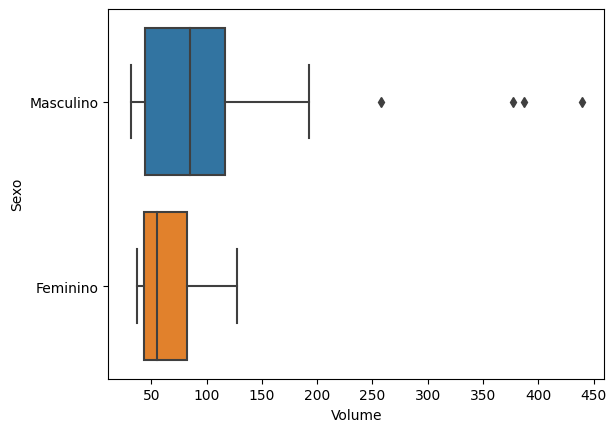

In [ ]:
#Faixa de vendas por sexo
import seaborn as sns
sns.boxplot(y=lista_livros["Sexo"], x=lista_livros['Volume'])

Quantidade de vendas entre os gêneros

<Axes: xlabel='Sexo'>

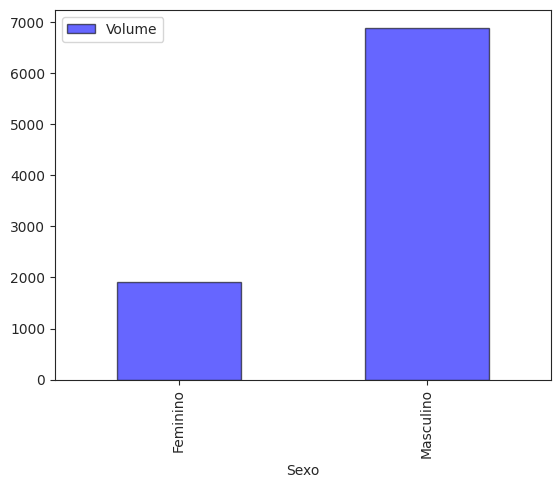

In [ ]:
import matplotlib.pyplot as plt
vendas_por_sexo = lista_livros.groupby(by=['Sexo'])['Volume'].sum()
qnt_vendas = pd.DataFrame(vendas_por_sexo)
qnt_vendas.plot.bar(color='blue', ec = 'k', alpha = 0.6)

Aqui é possível observar que a frequencia de quantidade de vendas de obras de autoras está mais presente entre 40 e 60 mil exemplares

<Axes: xlabel='Volume'>

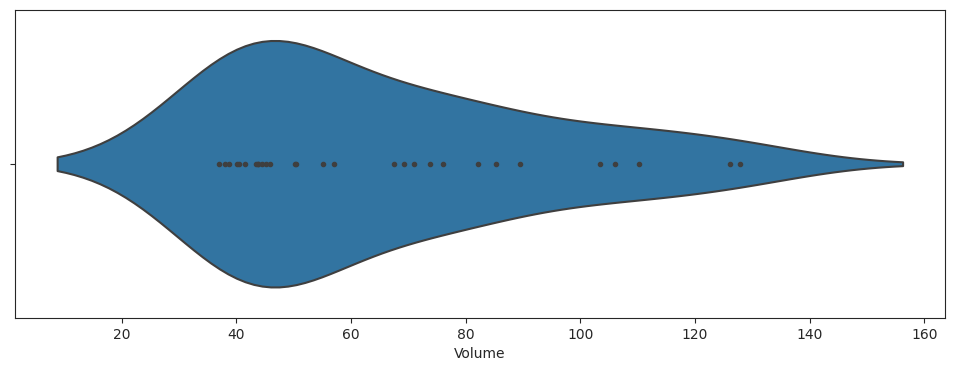

In [ ]:
grafico = sns.violinplot( x = 'Volume', data = lista_mulheres, orient ='h',inner="points")
grafico.figure.set_size_inches(12,4)
grafico

Evidência do volume de vendas de obras femininas por etnia

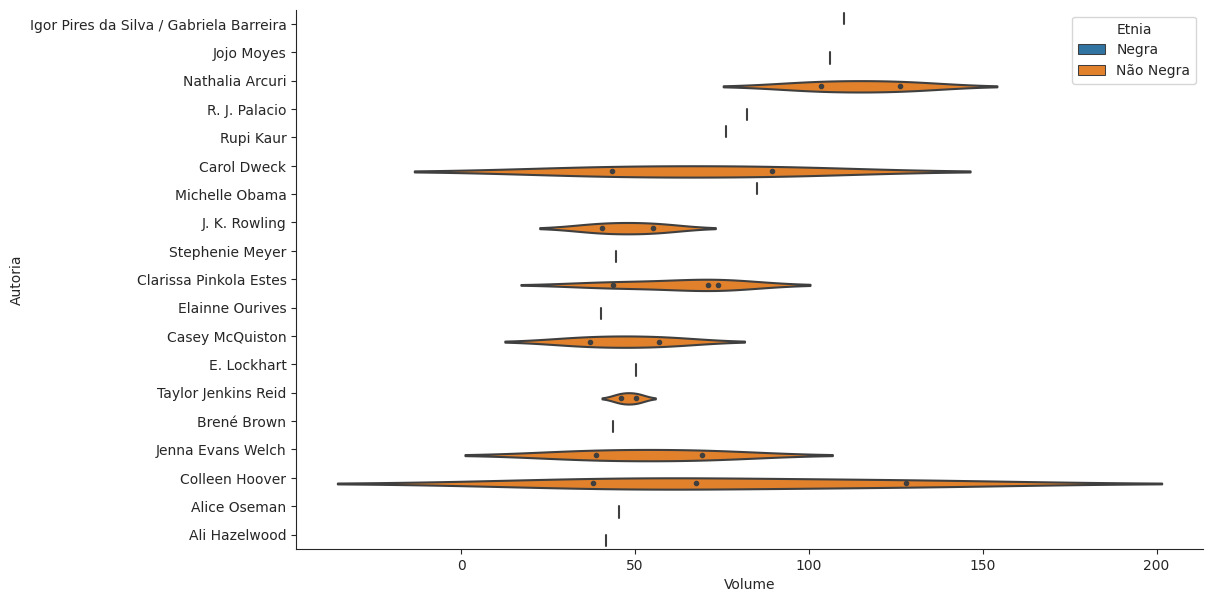

In [ ]:
import matplotlib.pyplot as plt
sns.set_style('ticks')
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(11.7, 7)
sns.violinplot(x=lista_mulheres['Volume'],y=lista_mulheres['Autoria'], inner="points", ax=ax, hue=lista_mulheres['Etnia'])
sns.despine()

Text(0.5, 1.0, 'Quantidade de Vendas por mês de obras de Autoras Negras nos últimos 5 anos')

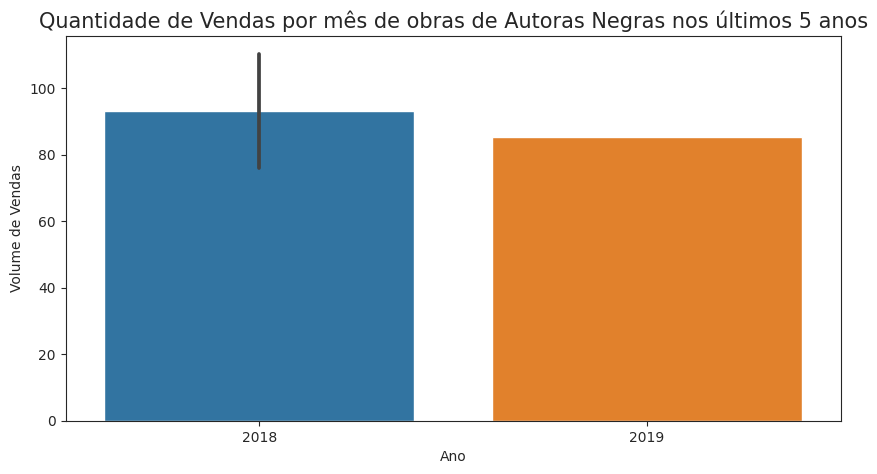

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Ano',y='Volume',data=lista_mulheres_negras)
ax.set_ylabel("Volume de Vendas")
ax.set_xlabel("Ano")
ax.set_title("Quantidade de Vendas por mês de obras de Autoras Negras nos últimos 5 anos",fontsize=15)
#plt.xticks(rotation = 25)

**6. Gtrends**

As observações abaixo foram feitas através da linguagem R, com base no experimento passado em sala de aula.

Apesar de Mark Manson ganhar em disparada no Ranking fornecido pela Publish News, no mesmo período, segundo o Google , a procura maior está nos títulos das autoras presentes nas listagens de 2018 a 2022.

Entre as autoras negras indicadas no Raking, nota-se que o termo Michele Obama foi o mais procurado, entretanto o livro "É assim que acaba" lidera as buscas feitas pelos usuários.


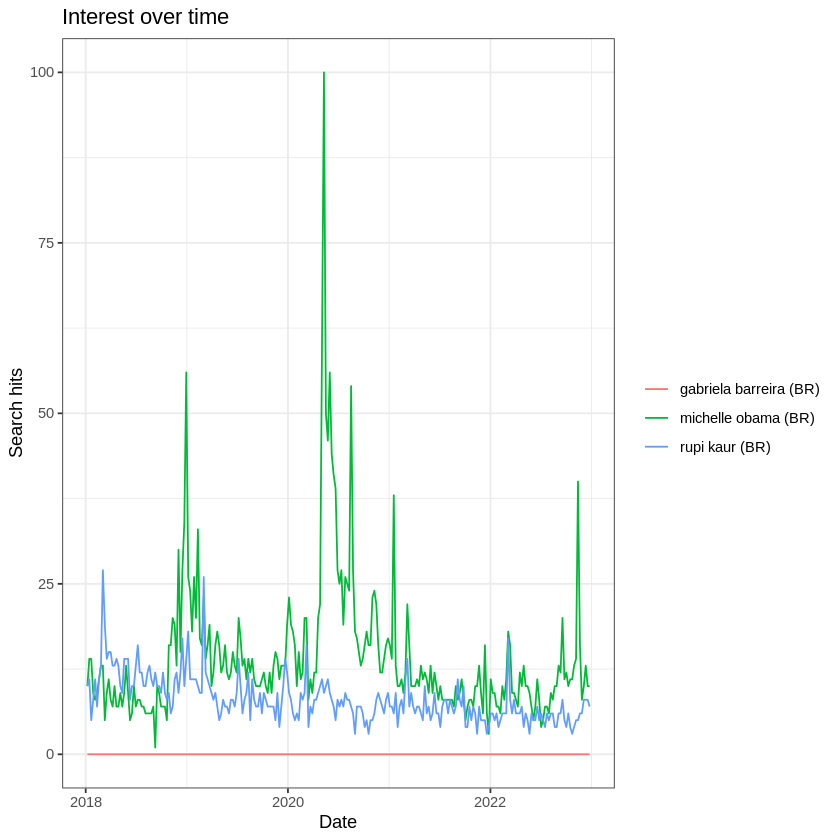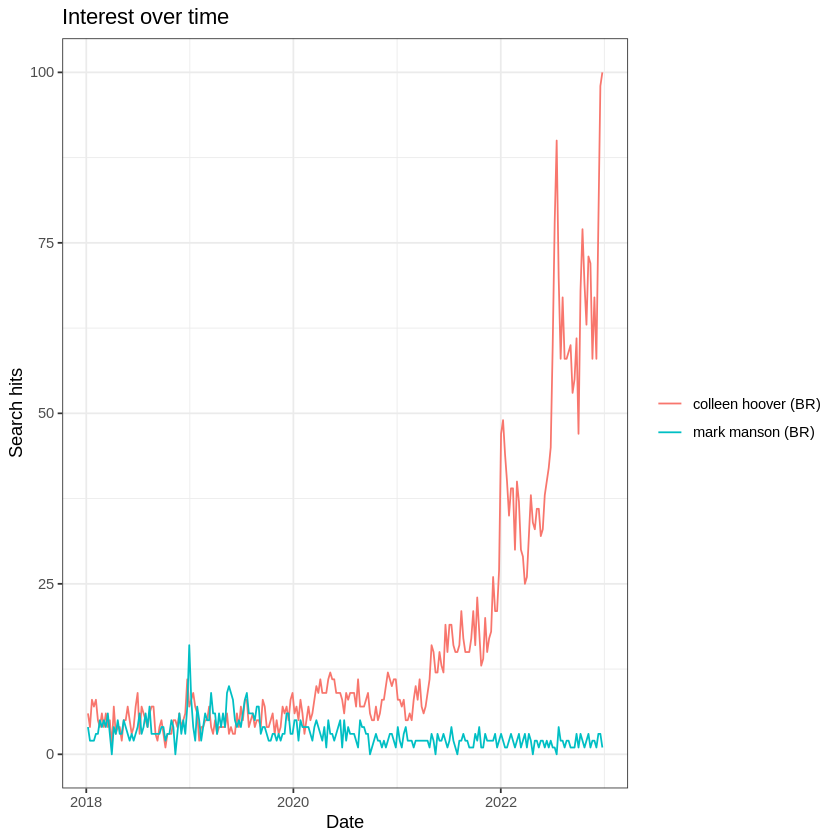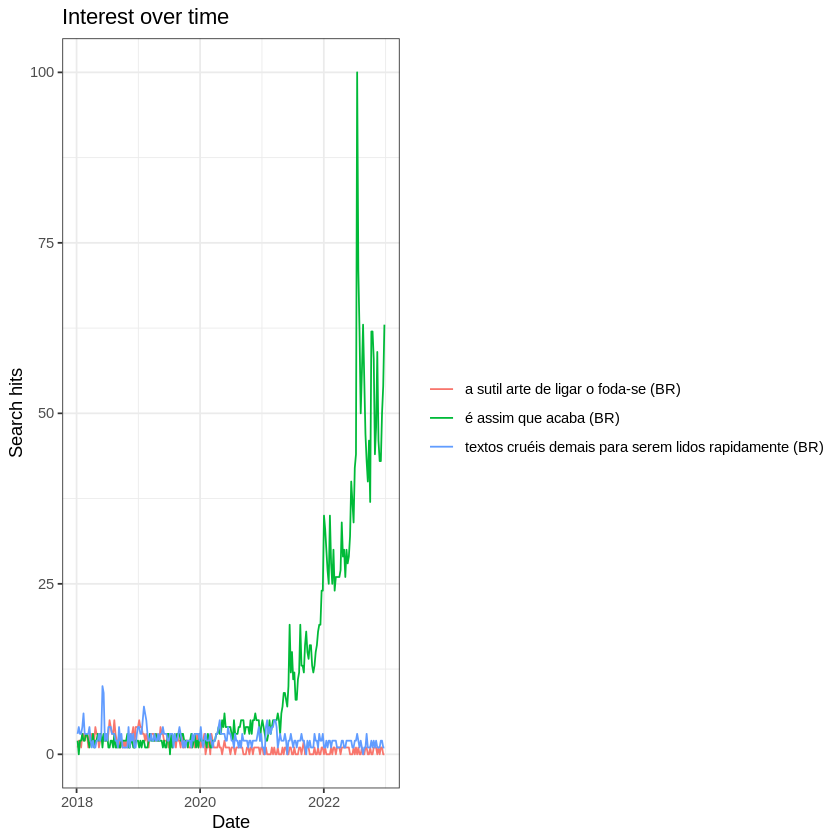

**6. Pontos Importantes**

Mesmo sendo uma amostra pequena e não oficial, é nítido que o ranking final não reflete um cenário literário muito diverso e que a presença de obras de autoras negras em nada se equipara a predominancia masculina presente nesse mercado, pois se tem apenas 3 titulos, de 3 autorias distintas, em um total de 99.
Apesar disso a criação desse ranking é um movimento que pode ser ampliado e receber maiores colaborações para que talvez um dia possa se tornar uma referência e/ou um retrato mais fiel ao mercado do livro brasileiro.

Entretanto esse exercicio possibilitou reflexões interessantes, que precisam ser melhor trabalhadas e poderiam enriquecer próximas manipulações de dados. Segue algumas delas:


- Há livrarias com enfoque em literatura negra, literatura feminina que pode agregar ao ranking?Isso ao menos já foi cogitado? Será que a quantidade e escolha de livrarias que participam da alimentação do Ranking influencia na posição das obras vendidas?. A falta de livrarias com acervo de vendas mais diverso pode favorecer à presença de vieses inconscientes e até mesmo vieses de gênero e raça na listagem fornecida para a construção do ranking.

- Outra exploração viável seria a execução de uma análise mais profunda, focada nos rankings mensais e semanais que o site também disponibiliza, para verificar se os padrões se repetem tanto em relação a participação feminina quanto de autoras negras presentes.

- Um fator de grande relevância é a localização e publico marjoritário das livrarias citadas, que pode ou não impactar no resultado do ranking. Qual o perfil dos usuários dessas livrarias? Qual classe social e etnia tem acesso a elas?

- Como as obras são divulgadas e trabalhadas? Qual o critério para se ter destaque e maior visibilidade do que a outra? Há ações voltadas para estimular o conhecimento do publico de obras de autoras negras?

- Será que o preço das obras impactam no volume de vendas?

- Qual a dificuldade, incentivo que mulheres tem em publicar? A falta de maior representatividade feminina negra no ranking anual do período de 2018 a 2022 reflete vieses presentes no mercado editorial brasileiro?

- A que ponto movimentos politicos e discursos do Governo vigente no periodo analisado influenciou na procura e venda de livros, especialmente de obras escritas por pessoas negras?

- O quanto esse cenário mudaria com a inclusão de venda de ebooks no mesmo período?

- Qual a percepção da sociedade perante obras de autores negros? Literatura negra é somente para negros? Qual o perfil de leitores de obras de autores negros em geral?

- O quanto o mercado de livros atual reflete a desigualdade racial no Brasil?

- Como é o tratamento e inclusão de obras de mulheres negras no mercado do livro no Brasil? Quem são os interessados e envolvidos nesse cenário?

# 4. Referências


[1] LANCER, H.A. Lancer ethnicity scale (LES). Lasers in Surgery and Medicine, v.22, n.1 p.9-9. https://doi.org/10.1002/(SICI)1096-9101(1998)22:1<9::AID-LSM4>3.0.CO;2-T

[2] MOLINA, David; CAUSA, Leonardo; TAPIA, Juan. Toward to Reduction of Bias for Gender and Ethnicity from
Face Images using Automated Skin Tone Classifification. A. Bromme, C. Busch, A. Dantcheva, K. Raja, C. Rathgeb and A. Uhl (Eds.): BIOSIG 2020, Lecture Notes in Informatics (LNI), Gesellschaft fur Informatik, Bonn 2020, p.281-289

[3] PUBLISH News. Home. Disponível em: https://www.publishnews.com.br/. Acesso em: 25 jul 2023.

[4] WIKIPEDIA. Escala de Fitzpatrick. Disponível em: https://pt.wikipedia.org/wiki/Escala_de_Fitzpatrick. Acesso em: 15 ago 2023


**4.1 Fontes que abordam assunto proposto pelo exercicio do trabalho final**

JUNIOR, Francis. Literatura reflete desigualdade racial no Brasil. Jornal da USP no ar. 2021. Disponível em: https://jornal.usp.br/atualidades/literatura-reflete-desigualdade-racial-no-brasil/ Acesso em 10 ago 2023

PUBLISH NEWS. 158 - Por mais espaços para mulheres no mercado Editorial - Dita Livros e Gato sem Rabo.Entrevistadas: Luciana Benatti, Johanna Stein.Podcast. 2021 Disponível em: https://open.spotify.com/episode/1YkzwyQpK3w2CubT9SZe6v?si=1fb34d686d6d46f1&nd=1 Acesso em 10 ago 2023

FUNDAÇÃO Tide Setubal.O viés racial das desigualdades. Notícias. 2017. Disponível em: https://fundacaotidesetubal.org.br/o-vies-racial-das-desigualdades/ Acesso em: 22 jul 2023.


HARAWAY, Donna. “Manifesto ciborgue: Ciência, tecnologia e feminismo-socialista no final do século XX” (1985). In: Tomaz Tadeu (org.). Antropologia do ciborgue: as vertigens do pós-humano. Belo Horizonte: Autêntica Editora, 2009 [2000]. Pp. 33-119.

O’NEIL, Cathy. Algoritmos de destruição em massa : como o big data aumenta a desigualdade e ameaça a Democracia.  Editora Rua do Sabão, 2020.

Vieses cognitivos: o que são, exemplos e como identificar. UCS Universidade Caxias do Sul. 2022. Disponível em:
https://ead.ucs.br/blog/vieses-cognitivos Acesso em: 25 jul 2023.

Vieses inconscientes, equidade de gênero e o mundo corporativo: lições da oficina “vieses inconscientes”. 2016.

Dias, Guilherme. Vieses inconscientes: o que são, exemplos e como combatê-los. Gupy Blog. 2022. Disponível em: https://www.gupy.io/blog/vieses-inconscientes#:~:text=Vieses%20inconscientes%20s%C3%A3o%20preconceitos%2C%20estere%C3%B3tipos,decis%C3%B5es%20tendenciosas%20e%20comportamentos%20prejudiciais. Acesso em: 06 Jul. 2023

Blog by juliana. Como evitar vieses na Inteligência Artificial?. Neuralmind. 2021. Disponível em: https://neuralmind.ai/2021/04/22/como-evitar-vieses-na-inteligencia-artificial/. Acesso em: 06 Jul. 2023.

FACCHINI, TALITA. A (Falta de) Diversidade no mercado editorial Brasileiro.
PUBLISHNEWS. 2022. Disponível em: https://www.publishnews.com.br/materias/2020/06/08/a-falta-de-diversidade-no-mercado-editorial-brasileiro. Acesso em 08 ago 2023

ROSÁRIO, Fernanda. Editoras independentes aceleram o crescimento de publicações de pessoas negras. Alma Preta: Jornalisto Preto e Livre. 2021. Disponível em: https://www.almapreta.com.br/sessao/literatura/editoras-independentes-aceleram-o-crescimento-de-publicacoes-de-pessoas-negras. Acesso em: 05 ago 2023


NEGREIROS, Dalila. 20 Livrarias e Editoras Negras e Indígenas. Medium. 2020. Disponível em: https://dalilanegreiros.medium.com/20-livrarias-e-editoras-negras-e-indígenas-47f69fc496b2. Acesso em 02 ago 2023

NASCIMENTO. Rakeche. Literatura e racismo: conheça 5 editoras pretas com livros incríveis para jovens e crianças. Mundo Negro. 2021. Disponível em: https://mundonegro.inf.br/literatura-e-racismo-conheca-5-editoras-pretas-com-livros-incriveis-para-jovens-e-criancas/. Acesso em: 05 ago 2023.